In [1]:
import numpy as np
from scipy.stats import ks_2samp
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
import sys
sys.path.append('../../py_files/')
#import weights
import control_sample as control
import BRAHMA_python as il_brahma
from tqdm import tqdm

import host_galaxy_enhancement_plots as hostplot
import host_utils as utils
from astropy.cosmology import Planck15
from astropy import units as u

In [2]:
import os
tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path
import scienceplots
plt.style.use('science')

In [3]:
pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/' 
tng_pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/'

print("For TNG50:")
TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
TNG_50_pop = control.load_pop_file(TNG_basepath,tng_pop_file_path,[0,0,1000,1])
TNG_50_control = control.control_samples_TNG(TNG_50_pop)
TNG_color = '#d95f02'


brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/"
brahma_simName_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
brahma_sim_colors = {
    brahma_simName_array[0]: '#bdc9e1', 
    brahma_simName_array[1]: '#67a9cf', 
    brahma_simName_array[2]: '#1c9099', 
    brahma_simName_array[3]: '#016c59',
    brahma_simName_array[4]: '#3690c0', 
    brahma_simName_array[5]: '#014636'  
}
brahma_sim_obj = {}
brahma_sim_zbins = {}
#brahma_sim_zbin_width = {}
for i,sim in enumerate(brahma_simName_array):
    print(sim)
    simPath = brahma_basepath + sim + '/'
    brahma_pop_Nstar10 = control.load_pop_file(simPath,pop_file_path,[0,0,10,1])
    brahma_control = control.control_sample_brahma(brahma_pop_Nstar10)
    brahma_sim_obj[sim] = brahma_control
    #brahma_sim_zbin_width,brahma_sim_zbins[sim] =hostplot.find_best_z_width(brahma_control.z_merging_pop,z_min=0,z_max=10,z_width_initial=0.2)
    brahma_sim_zbins[sim] = hostplot.find_adaptive_z_bins(brahma_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.2,min_N_values=10)
    


TNG_50_zbins = hostplot.find_adaptive_z_bins(TNG_50_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.3,min_N_values=50)
print('TNG50',TNG_50_zbins )
brahma_zbins = hostplot.find_brahma_adaptive_z_bins(brahma_sim_obj,brahma_simName_array,z_lower=0,z_max=10,zbin_width=0.1,min_N_values=10)
print('Brahma common zbins:',brahma_zbins)


sim_names = brahma_simName_array + ['TNG50']
sim_colors = {sim: brahma_sim_colors[sim] for sim in brahma_simName_array}
sim_colors['TNG50'] = TNG_color
sim_objs = brahma_sim_obj
sim_objs['TNG50'] = TNG_50_control
sim_zbins_list = brahma_sim_zbins
#sim_zbins_list = {sim: brahma_zbins for sim in brahma_simName_array}
sim_zbins_list['TNG50'] = TNG_50_zbins

For TNG50:


processing each merger redshifts for controls: 100%|██████████| 83/83 [00:02<00:00, 36.62it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:362: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of available mergers in this population is 504
Number of cases where a close enough match is not found within the acceptable tolerance: 14
SM5_TNG


finding controls: 100%|██████████| 796/796 [00:00<00:00, 22439.53it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:632: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:636: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_massive_pop = self.Mdot_massive_control_pop/self.MBH_massive_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:639: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_luminous_pop = self.Mdot_luminous_control_pop/self.MBH_luminous_control_pop


Number of cases where a close enough match is not found within the acceptable tolerance: 173
number of processable mergers with valid controls:
603
[22, 20, 37, 53, 89, 88, 112, 87, 42, 31, 15]
SM5_LW10_TNG


...

Number of cases where a close enough match is not found within the acceptable tolerance: 424
number of processable mergers with valid controls:
695
[38, 40, 47, 86, 103, 86, 115, 84, 59, 20, 12]
SM5_LW10_LOWSPIN_TNG


finding controls: 100%|██████████| 494/494 [00:00<00:00, 23215.79it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 119
number of processable mergers with valid controls:
366
[21, 17, 13, 30, 40, 35, 68, 51, 35, 25, 19, 10]
SM5_LW10_LOWSPIN_RICH_TNG


finding controls: 100%|██████████| 177/177 [00:00<00:00, 22411.83it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 46
number of processable mergers with valid controls:
130
[10, 15, 16, 13, 19, 13, 17, 12, 13]
[55, 57, 54, 63, 65, 57, 70, 50]
TNG50 [0.  0.3 0.6 0.9 1.3 1.7 2.1 2.6 3.8]
Brahma common zbins: [0.  0.2 0.8 1.4 2.  2.6 3.2 4.1 5.  8.1]


In [4]:
# Find unique redshifts in the range 4 < z < 5 for SM5_DFD_3_TNG
highz_mask_for_sm5_dfd_3 = (sim_objs['SM5_DFD_3_TNG'].z_merging_pop >= 4) & (sim_objs['SM5_DFD_3_TNG'].z_merging_pop < 5)
unique_z = np.unique(sim_objs['SM5_DFD_3_TNG'].z_merging_pop[highz_mask_for_sm5_dfd_3])

print(f"Unique redshifts in range (4 < z < 5) for SM5_DFD_3_TNG:")
print(f"Number of unique z values: {len(unique_z)}")
print(f"Min z: {unique_z.min():.4f}")
print(f"Max z: {unique_z.max():.4f}")
print(f"\nAll unique z values:")
print(unique_z)

# Also show counts per redshift
z_counts = np.unique(sim_objs['SM5_DFD_3_TNG'].z_merging_pop[highz_mask_for_sm5_dfd_3], return_counts=True)
print(f"\nRedshift bins with galaxy counts:")
for z, count in zip(z_counts[0], z_counts[1]):
    print(f"  z = {z:.4f}: {count} galaxies")

Unique redshifts in range (4 < z < 5) for SM5_DFD_3_TNG:
Number of unique z values: 2
Min z: 4.0079
Max z: 4.9959

All unique z values:
[4.00794511 4.99593347]

Redshift bins with galaxy counts:
  z = 4.0079: 54 galaxies
  z = 4.9959: 36 galaxies


In [10]:
z4_mask = sim_objs['SM5_DFD_3_TNG'].z_merging_pop == unique_z[0]
z5_mask = sim_objs['SM5_DFD_3_TNG'].z_merging_pop == unique_z[1]

Text(0.5, 1.0, 'SM5_DFD_3_TNG [z$\\sim$5]')

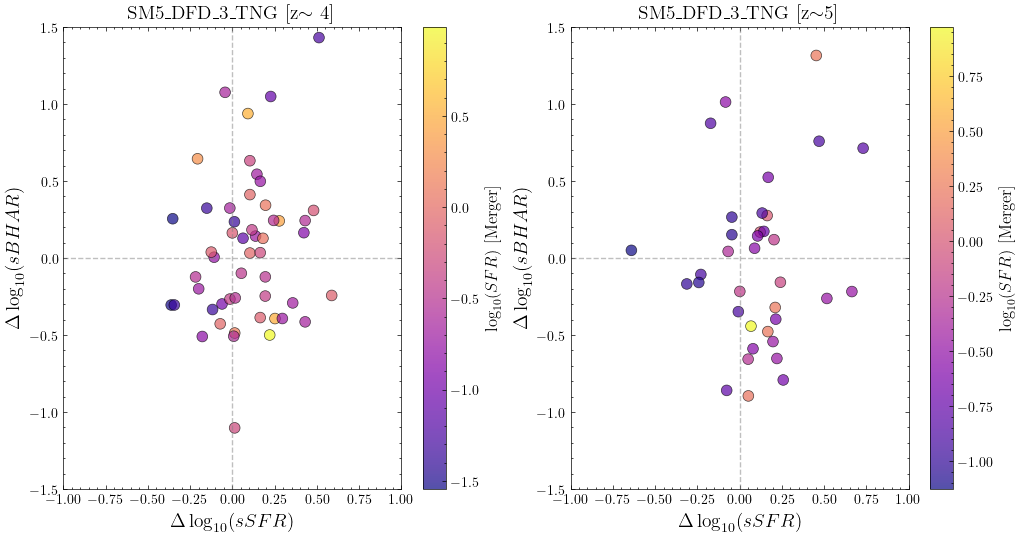

In [13]:
fig,axes = plt.subplots(1,2,figsize=(12,6))

sSFR_merger = sim_objs['SM5_DFD_3_TNG'].sSFR_merging_pop[z4_mask]
sSFR_control = sim_objs['SM5_DFD_3_TNG'].sSFR_control_pop[z4_mask]
sBHAR_merger = sim_objs['SM5_DFD_3_TNG'].sBHAR_merging_massive_pop[z4_mask]
sBHAR_control = sim_objs['SM5_DFD_3_TNG'].sBHAR_control_massive_pop[z4_mask]

# Filter valid data (positive values, no NaNs)
valid_mask = (sSFR_merger > 0) & (sSFR_control > 0) & (sBHAR_merger > 0) & (sBHAR_control > 0) & \
             (~np.isnan(sSFR_merger)) & (~np.isnan(sSFR_control)) & (~np.isnan(sBHAR_merger)) & (~np.isnan(sBHAR_control))
sSFR_enhancement = np.log10(sSFR_merger[valid_mask] / sSFR_control[valid_mask])
sBHAR_enhancement = np.log10(sBHAR_merger[valid_mask] / sBHAR_control[valid_mask])

SFR_merger = sim_objs['SM5_DFD_3_TNG'].SFR_merging_pop[z4_mask][valid_mask]
scatter = axes[0].scatter(sSFR_enhancement,sBHAR_enhancement, c=np.log10(SFR_merger), 
                     alpha=0.7, s=60, edgecolors='k', linewidth=0.5, cmap='plasma')
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label(r'$\log_{10}(SFR)$ [Merger]', fontsize=12)
scatter.set_clim(np.min(np.log10(SFR_merger)), np.max(np.log10(SFR_merger)))
axes[0].set_xlabel(r'$\Delta \log_{10}(sSFR)$', fontsize=14)
axes[0].set_ylabel(r'$\Delta \log_{10}(sBHAR)$', fontsize=14)
axes[0].axhline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[0].axvline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[0].set_xlim(-1,1)
axes[0].set_ylim(-1.5,1.5)
axes[0].set_title(f'SM5_DFD_3_TNG [z$\sim${int(unique_z[0]):2d}]', fontsize=14)


sSFR_merger = sim_objs['SM5_DFD_3_TNG'].sSFR_merging_pop[z5_mask]
sSFR_control = sim_objs['SM5_DFD_3_TNG'].sSFR_control_pop[z5_mask]
sBHAR_merger = sim_objs['SM5_DFD_3_TNG'].sBHAR_merging_massive_pop[z5_mask]
sBHAR_control = sim_objs['SM5_DFD_3_TNG'].sBHAR_control_massive_pop[z5_mask]

# Filter valid data (positive values, no NaNs)
valid_mask = (sSFR_merger > 0) & (sSFR_control > 0) & (sBHAR_merger > 0) & (sBHAR_control > 0) & \
             (~np.isnan(sSFR_merger)) & (~np.isnan(sSFR_control)) & (~np.isnan(sBHAR_merger)) & (~np.isnan(sBHAR_control))
sSFR_enhancement = np.log10(sSFR_merger[valid_mask] / sSFR_control[valid_mask])
sBHAR_enhancement = np.log10(sBHAR_merger[valid_mask] / sBHAR_control[valid_mask])
SFR_merger = sim_objs['SM5_DFD_3_TNG'].SFR_merging_pop[z5_mask][valid_mask]
scatter = axes[1].scatter(sSFR_enhancement,sBHAR_enhancement, c=np.log10(SFR_merger),
                        alpha=0.7, s=60, edgecolors='k', linewidth=0.5, cmap='plasma')
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label(r'$\log_{10}(SFR)$ [Merger]', fontsize=12)
scatter.set_clim(np.min(np.log10(SFR_merger)), np.max(np.log10(SFR_merger)))
axes[1].set_xlabel(r'$\Delta \log_{10}(sSFR)$', fontsize=14)
axes[1].set_ylabel(r'$\Delta \log_{10}(sBHAR)$', fontsize=14)
axes[1].axhline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[1].axvline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[1].set_xlim(-1,1)
axes[1].set_ylim(-1.5,1.5)
axes[1].set_title(f'SM5_DFD_3_TNG [z$\sim$5]', fontsize=14)


In [14]:
#z=4

sSFR_merger = sim_objs['SM5_DFD_3_TNG'].sSFR_merging_pop[z4_mask]
sSFR_control = sim_objs['SM5_DFD_3_TNG'].sSFR_control_pop[z4_mask]
sBHAR_merger = sim_objs['SM5_DFD_3_TNG'].sBHAR_merging_massive_pop[z4_mask]
sBHAR_control = sim_objs['SM5_DFD_3_TNG'].sBHAR_control_massive_pop[z4_mask]


# Filter valid data (positive values, no NaNs)
valid_mask = (sSFR_merger > 0) & (sSFR_control > 0) & (sBHAR_merger > 0) & (sBHAR_control > 0) & \
             (~np.isnan(sSFR_merger)) & (~np.isnan(sSFR_control)) & (~np.isnan(sBHAR_merger)) & (~np.isnan(sBHAR_control))
sSFR_enhancement = np.log10(sSFR_merger[valid_mask] / sSFR_control[valid_mask])
sBHAR_enhancement = np.log10(sBHAR_merger[valid_mask] / sBHAR_control[valid_mask])

#values where the sSFR enhancement is positive but sBHAR enhancement is negative
positive_sSFR_negative_sBHAR_mask = (sSFR_enhancement > 0) & (sBHAR_enhancement < 0)
num_positive_sSFR_negative_sBHAR = np.sum(positive_sSFR_negative_sBHAR_mask)
print(f"\nNumber of galaxies with dSFR>0 but dsBHAR<0 at z={unique_z[0]:.4f}: {num_positive_sSFR_negative_sBHAR}")
mask_positive_sSFR_negative_sBHAR = valid_mask.copy()
mask_positive_sSFR_negative_sBHAR[valid_mask] = positive_sSFR_negative_sBHAR_mask

#indices of galaxies with positive sSFR enhancement but negative sBHAR enhancement



Number of galaxies with dSFR>0 but dsBHAR<0 at z=4.0079: 14


In [15]:
sim_objs['SM5_DFD_3_TNG'].z_merging_pop[z4_mask][mask_positive_sSFR_negative_sBHAR]

array([4.00794511, 4.00794511, 4.00794511, 4.00794511, 4.00794511,
       4.00794511, 4.00794511, 4.00794511, 4.00794511, 4.00794511,
       4.00794511, 4.00794511, 4.00794511, 4.00794511])

In [16]:
sim_objs['SM5_DFD_3_TNG'].subhalo_ids_mergers[z4_mask][valid_mask][positive_sSFR_negative_sBHAR_mask]

array([1243,  978, 4538, 2157, 3138, 3934,  569, 2296, 3002, 4315, 1727,
       3567, 2795, 2893])

In [17]:
sim_objs['SM5_DFD_3_TNG'].subhalo_ids_controls[z4_mask][valid_mask][positive_sSFR_negative_sBHAR_mask]

array([2569,  671, 3040, 3598, 3240, 4907,  803, 2600, 3628, 3752, 1143,
       4004, 3982, 2509])

In [19]:
sim_objs['SM5_DFD_3_TNG'].fgas_merging_pop[z4_mask][valid_mask][positive_sSFR_negative_sBHAR_mask]

array([0.97138051, 0.95016383, 0.9789302 , 0.98340637, 0.97234344,
       0.96920324, 0.94058717, 0.97250278, 0.97433647, 0.98290719,
       0.96854728, 0.95161373, 0.96980596, 0.95527994])

In [20]:
sim_objs['SM5_DFD_3_TNG'].fgas_control_pop[z4_mask][valid_mask][positive_sSFR_negative_sBHAR_mask]

array([0.93985901, 0.93250588, 0.88619549, 0.95853603, 0.97677761,
       0.94353973, 0.89981097, 0.96498659, 0.95916589, 0.98436516,
       0.95544987, 0.92775567, 0.93324851, 0.95850126])

In [21]:
merger_indices = sim_objs['SM5_DFD_3_TNG'].merger_control_index_pairs[sim_objs['SM5_DFD_3_TNG'].valid_control_mask,0]

In [22]:
control_indices = sim_objs['SM5_DFD_3_TNG'].merger_control_index_pairs[sim_objs['SM5_DFD_3_TNG'].valid_control_mask,1]

In [23]:
sim_objs['SM5_DFD_3_TNG'].z_merging_pop[z4_mask][mask_positive_sSFR_negative_sBHAR]

array([4.00794511, 4.00794511, 4.00794511, 4.00794511, 4.00794511,
       4.00794511, 4.00794511, 4.00794511, 4.00794511, 4.00794511,
       4.00794511, 4.00794511, 4.00794511, 4.00794511])

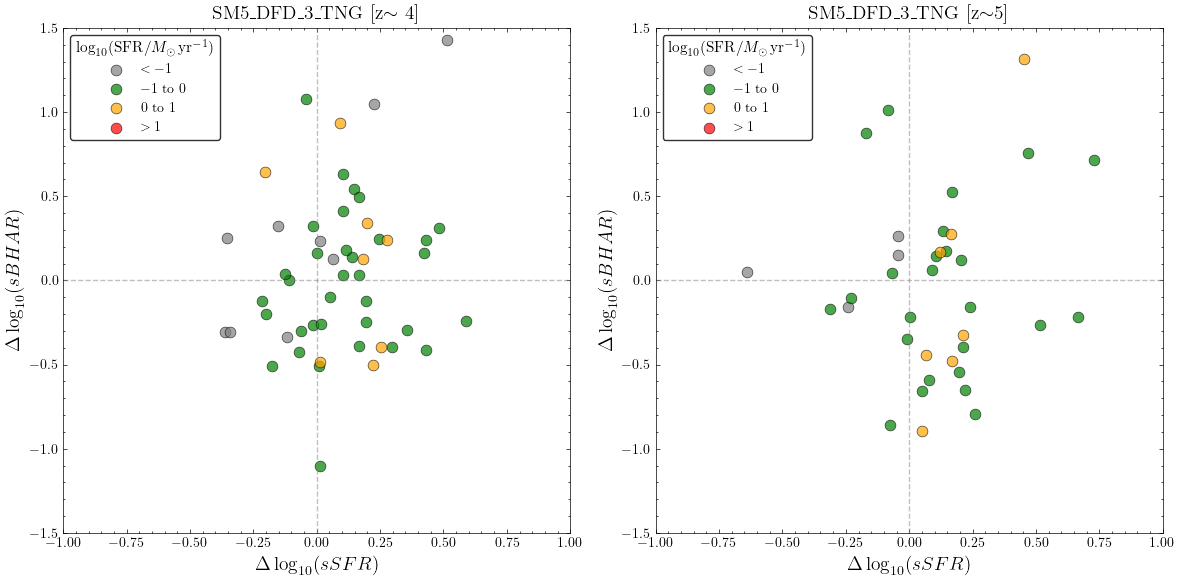

In [52]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Define SFR bins (in log10 space) and colors
sfr_bins = [-np.inf, -1, 0, 1, np.inf]
sfr_colors = ['grey', 'green', 'orange', 'red']
sfr_labels = [
    r'$<-1$', r'$-1$ to $0$', r'$0$ to $1$', r'$>1$'
]
for i, (mask, ax, zlabel) in enumerate(zip([z4_mask, z5_mask], axes, [f'z$\sim${int(unique_z[0]):2d}', 'z$\sim$5'])):
    sSFR_merger = sim_objs['SM5_DFD_3_TNG'].sSFR_merging_pop[mask]
    sSFR_control = sim_objs['SM5_DFD_3_TNG'].sSFR_control_pop[mask]
    sBHAR_merger = sim_objs['SM5_DFD_3_TNG'].sBHAR_merging_massive_pop[mask]
    sBHAR_control = sim_objs['SM5_DFD_3_TNG'].sBHAR_control_massive_pop[mask]
    SFR_merger = sim_objs['SM5_DFD_3_TNG'].SFR_merging_pop[mask]

    valid_mask = (sSFR_merger > 0) & (sSFR_control > 0) & (sBHAR_merger > 0) & (sBHAR_control > 0) & \
                 (~np.isnan(sSFR_merger)) & (~np.isnan(sSFR_control)) & (~np.isnan(sBHAR_merger)) & (~np.isnan(sBHAR_control))
    sSFR_enhancement = np.log10(sSFR_merger[valid_mask] / sSFR_control[valid_mask])
    sBHAR_enhancement = np.log10(sBHAR_merger[valid_mask] / sBHAR_control[valid_mask])
    log_SFR_merger = np.log10(SFR_merger[valid_mask])

    # Plot each SFR bin with its color
    for j in range(len(sfr_bins) - 1):
        bin_mask = (log_SFR_merger > sfr_bins[j]) & (log_SFR_merger <= sfr_bins[j+1])
        ax.scatter(
            sSFR_enhancement[bin_mask], sBHAR_enhancement[bin_mask],
            color=sfr_colors[j], alpha=0.7, s=60, edgecolors='k', linewidth=0.5, label=sfr_labels[j]
        )

    ax.set_xlabel(r'$\Delta \log_{10}(sSFR)$', fontsize=14)
    ax.set_ylabel(r'$\Delta \log_{10}(sBHAR)$', fontsize=14)
    ax.axhline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
    ax.axvline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(f'SM5_DFD_3_TNG [{zlabel}]', fontsize=14)
    ax.legend(title=r'$\log_{10}(\mathrm{SFR}/M_\odot\,\mathrm{yr}^{-1})$', fontsize=10, title_fontsize=11, loc='best', frameon=True, edgecolor='black')

plt.tight_layout()

Text(0.5, 1.0, 'SM5_DFD_3_TNG [z$\\sim$5]')

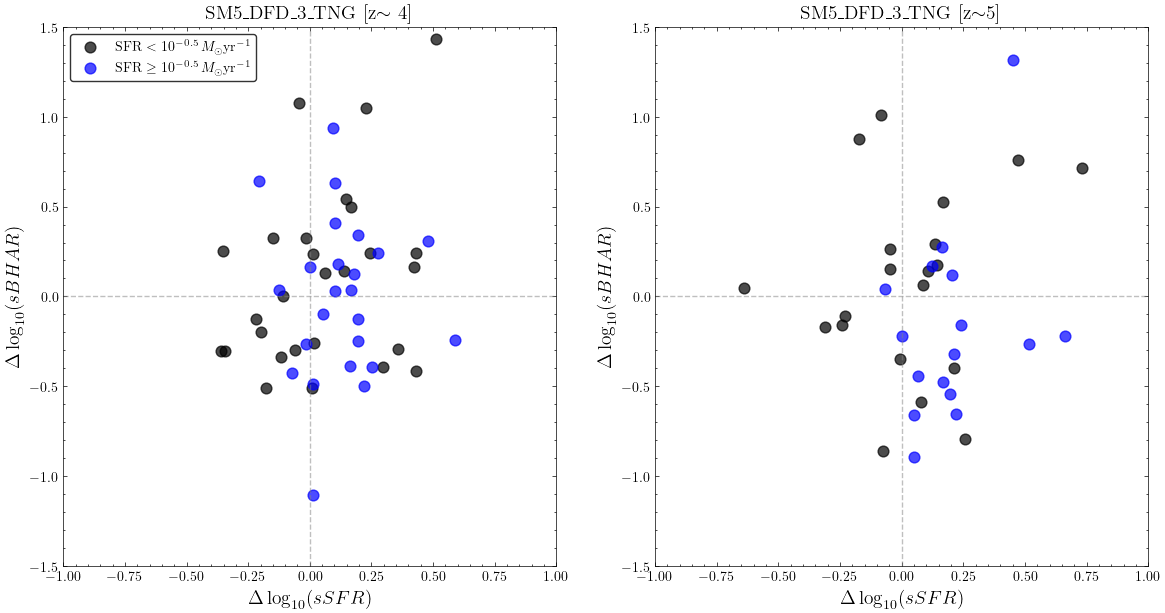

In [27]:
fig,axes = plt.subplots(1,2,figsize=(14,7))

sSFR_merger = sim_objs['SM5_DFD_3_TNG'].sSFR_merging_pop[z4_mask]
sSFR_control = sim_objs['SM5_DFD_3_TNG'].sSFR_control_pop[z4_mask]
sBHAR_merger = sim_objs['SM5_DFD_3_TNG'].sBHAR_merging_massive_pop[z4_mask]
sBHAR_control = sim_objs['SM5_DFD_3_TNG'].sBHAR_control_massive_pop[z4_mask]

# Filter valid data (positive values, no NaNs)
valid_mask = (sSFR_merger > 0) & (sSFR_control > 0) & (sBHAR_merger > 0) & (sBHAR_control > 0) & \
             (~np.isnan(sSFR_merger)) & (~np.isnan(sSFR_control)) & (~np.isnan(sBHAR_merger)) & (~np.isnan(sBHAR_control))
sSFR_enhancement = np.log10(sSFR_merger[valid_mask] / sSFR_control[valid_mask])
sBHAR_enhancement = np.log10(sBHAR_merger[valid_mask] / sBHAR_control[valid_mask])

log_SFR_merger = np.log10(sim_objs['SM5_DFD_3_TNG'].SFR_merging_pop[z4_mask][valid_mask])
high_SF_galaxy_mask = log_SFR_merger >= -0.5 # Example threshold for high SFR (SFR > 10 M_sun/yr)
low_SF_galaxy_mask = log_SFR_merger < -0.5


scatter_low_SF = axes[0].scatter(sSFR_enhancement[low_SF_galaxy_mask], sBHAR_enhancement[low_SF_galaxy_mask], 
                        color="black",alpha=0.7, s=60, edgecolors='k',  label=r'SFR $< 10^{-0.5}\, M_\odot \mathrm{yr}^{-1}$')
scatter_high_SF = axes[0].scatter(sSFR_enhancement[high_SF_galaxy_mask], sBHAR_enhancement[high_SF_galaxy_mask], 
                            color="blue",alpha=0.7, s=60, label=r'SFR $\geq 10^{-0.5} \, M_\odot \mathrm{yr}^{-1}$')      
axes[0].set_xlabel(r'$\Delta \log_{10}(sSFR)$', fontsize=14)
axes[0].set_ylabel(r'$\Delta \log_{10}(sBHAR)$', fontsize=14)
axes[0].axhline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[0].axvline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[0].set_xlim(-1,1)
axes[0].set_ylim(-1.5,1.5)
axes[0].legend(fontsize=10, loc='best',frameon=True, edgecolor='black')
axes[0].set_title(f'SM5_DFD_3_TNG [z$\sim${int(unique_z[0]):2d}]', fontsize=14)


sSFR_merger = sim_objs['SM5_DFD_3_TNG'].sSFR_merging_pop[z5_mask]
sSFR_control = sim_objs['SM5_DFD_3_TNG'].sSFR_control_pop[z5_mask]
sBHAR_merger = sim_objs['SM5_DFD_3_TNG'].sBHAR_merging_massive_pop[z5_mask]
sBHAR_control = sim_objs['SM5_DFD_3_TNG'].sBHAR_control_massive_pop[z5_mask]


valid_mask = (sSFR_merger > 0) & (sSFR_control > 0) & (sBHAR_merger > 0) & (sBHAR_control > 0) & \
             (~np.isnan(sSFR_merger)) & (~np.isnan(sSFR_control)) & (~np.isnan(sBHAR_merger)) & (~np.isnan(sBHAR_control))
sSFR_enhancement = np.log10(sSFR_merger[valid_mask] / sSFR_control[valid_mask])
sBHAR_enhancement = np.log10(sBHAR_merger[valid_mask] / sBHAR_control[valid_mask])

log_SFR_merger = np.log10(sim_objs['SM5_DFD_3_TNG'].SFR_merging_pop[z5_mask][valid_mask])
high_SF_galaxy_mask = log_SFR_merger >= -0.5 # Example threshold for high SFR (SFR > 10 M_sun/yr)
low_SF_galaxy_mask = log_SFR_merger < -0.5


scatter_low_SF = axes[1].scatter(sSFR_enhancement[low_SF_galaxy_mask], sBHAR_enhancement[low_SF_galaxy_mask], 
                        color="black",alpha=0.7, s=60, edgecolors='k',  label=r'sSFR $< 10^{-8.5}\, \mathrm{yr}^{-1}$')
scatter_high_SF = axes[1].scatter(sSFR_enhancement[high_SF_galaxy_mask], sBHAR_enhancement[high_SF_galaxy_mask], 
                            color="blue",alpha=0.7, s=60, label=r'sSFR $\geq 10^{-8.5} \, \mathrm{yr}^{-1}$')      


axes[1].set_xlabel(r'$\Delta \log_{10}(sSFR)$', fontsize=14)
axes[1].set_ylabel(r'$\Delta \log_{10}(sBHAR)$', fontsize=14)
axes[1].axhline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[1].axvline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[1].set_xlim(-1,1)
axes[1].set_ylim(-1.5,1.5)
axes[1].set_title(f'SM5_DFD_3_TNG [z$\sim$5]', fontsize=14)


Unique redshifts in range (0 < z < 1) for TNG50:
Number of unique z values: 49
Min z: 0.0000
Max z: 0.9973


/tmp/ipykernel_246436/3102563689.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12, loc='best')


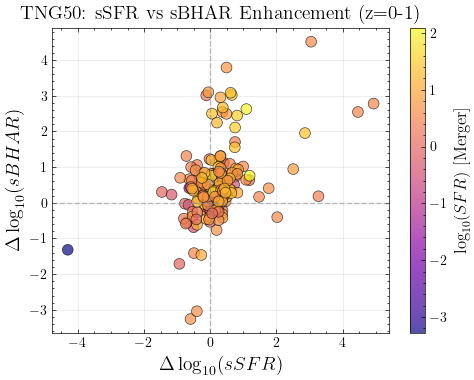

In [21]:
# Find unique redshifts for TNG50
lowz_mask_for_tng50 = (sim_objs['TNG50'].z_merging_pop >= 0) & (sim_objs['TNG50'].z_merging_pop < 1)
unique_z_tng50 = np.unique(sim_objs['TNG50'].z_merging_pop[lowz_mask_for_tng50])

print(f"Unique redshifts in range (0 < z < 1) for TNG50:")
print(f"Number of unique z values: {len(unique_z_tng50)}")
print(f"Min z: {unique_z_tng50.min():.4f}")
print(f"Max z: {unique_z_tng50.max():.4f}")

# Find correlation between sSFR and sBHAR enhancement at low-z for TNG50
sSFR_merger_tng = sim_objs['TNG50'].sSFR_merging_pop[lowz_mask_for_tng50]
sSFR_control_tng = sim_objs['TNG50'].sSFR_control_pop[lowz_mask_for_tng50]
sBHAR_merger_tng = sim_objs['TNG50'].sBHAR_merging_pop[lowz_mask_for_tng50]
sBHAR_control_tng = sim_objs['TNG50'].sBHAR_control_pop[lowz_mask_for_tng50]

# Filter valid data
valid_mask_tng = (sSFR_merger_tng > 0) & (sSFR_control_tng > 0) & (sBHAR_merger_tng > 0) & (sBHAR_control_tng > 0) & \
                 (~np.isnan(sSFR_merger_tng)) & (~np.isnan(sSFR_control_tng)) & (~np.isnan(sBHAR_merger_tng)) & (~np.isnan(sBHAR_control_tng))

sSFR_enhancement_tng = np.log10(sSFR_merger_tng[valid_mask_tng] / sSFR_control_tng[valid_mask_tng])
sBHAR_enhancement_tng = np.log10(sBHAR_merger_tng[valid_mask_tng] / sBHAR_control_tng[valid_mask_tng])

fig, ax = plt.subplots(figsize=(5,4))

# Get SFR values for color coding
SFR_merger_tng = sim_objs['TNG50'].SFR_merging_pop[lowz_mask_for_tng50][valid_mask_tng]

# Create scatter plot with SFR as color
scatter = ax.scatter(sSFR_enhancement_tng, sBHAR_enhancement_tng, c=np.log10(SFR_merger_tng), 
                     alpha=0.7, s=60, edgecolors='k', linewidth=0.5, cmap='plasma')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r'$\log_{10}(SFR)$ [Merger]', fontsize=12)

ax.set_xlabel(r'$\Delta \log_{10}(sSFR)$', fontsize=14)
ax.set_ylabel(r'$\Delta \log_{10}(sBHAR)$', fontsize=14)
ax.set_title(f'TNG50: sSFR vs sBHAR Enhancement (z=0-1)', fontsize=14, fontweight='bold')
ax.axhline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
ax.axvline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc='best')
fig.tight_layout()
plt.show()

In [32]:
# Export selected pairs to an HDF5 file with one dataset per field.
def extract_paired_samples_by_enhancement(sim_obj, sim_name, z_min, z_max, basePath,
                                           ssfr_enh_criterion='positive',
                                           sbhar_enh_criterion='negative',
                                           output_file=None):
    z_mask = (sim_obj.z_merging_pop >= z_min) & (sim_obj.z_merging_pop < z_max)

    sSFR_merger = sim_obj.sSFR_merging_pop[z_mask]
    sSFR_control = sim_obj.sSFR_control_pop[z_mask]
    sBHAR_merger = sim_obj.sBHAR_merging_pop[z_mask]
    sBHAR_control = sim_obj.sBHAR_control_pop[z_mask]

    valid_mask = (sSFR_merger > 0) & (sSFR_control > 0) & (sBHAR_merger > 0) & (sBHAR_control > 0) & \
                 (~np.isnan(sSFR_merger)) & (~np.isnan(sSFR_control)) & (~np.isnan(sBHAR_merger)) & (~np.isnan(sBHAR_control))

    sSFR_enhancement = np.log10(sSFR_merger[valid_mask] / sSFR_control[valid_mask])
    sBHAR_enhancement = np.log10(sBHAR_merger[valid_mask] / sBHAR_control[valid_mask])

    if ssfr_enh_criterion == 'positive':
        ssfr_mask = sSFR_enhancement > 0
    elif ssfr_enh_criterion == 'negative':
        ssfr_mask = sSFR_enhancement < 0
    else:
        raise ValueError("ssfr_enh_criterion must be 'positive' or 'negative'")

    if sbhar_enh_criterion == 'positive':
        sbhar_mask = sBHAR_enhancement > 0
    elif sbhar_enh_criterion == 'negative':
        sbhar_mask = sBHAR_enhancement < 0
    else:
        raise ValueError("sbhar_enh_criterion must be 'positive' or 'negative'")

    enhancement_mask = ssfr_mask & sbhar_mask

    merger_subhalo_ids_selected = np.asarray(
        sim_obj.subhalo_ids_mergers[z_mask][valid_mask][enhancement_mask],
        dtype=np.int64,
    )
    control_subhalo_ids_selected = np.asarray(
        sim_obj.subhalo_ids_controls[z_mask][valid_mask][enhancement_mask],
        dtype=np.int64,
    )
    redshifts_merger = np.asarray(
        sim_obj.z_merging_pop[z_mask][valid_mask][enhancement_mask],
        dtype=float,
    )

    pair_rows = np.asarray(sim_obj.merger_control_index_pairs)[np.asarray(sim_obj.valid_control_mask)]
    pair_merger_rows = pair_rows[:, 0].astype(np.int64)
    pair_control_rows = pair_rows[:, 1].astype(np.int64)

    merger_rows_selected = pair_merger_rows[z_mask][valid_mask][enhancement_mask]
    control_rows_selected = pair_control_rows[z_mask][valid_mask][enhancement_mask]

    merger_snaps_selected = np.asarray(
        sim_obj.pop['merging_population']['snap'][:][merger_rows_selected],
        dtype=np.int64,
    )
    control_snaps_selected = np.asarray(
        sim_obj.pop['non_merging_population']['snap'][:][control_rows_selected],
        dtype=np.int64,
    )

    is_brahma = 'TNG50-1' not in basePath

    def load_particle_counts(snaps_selected, subhalo_ids_selected):
        counts = np.full((len(subhalo_ids_selected), 4), -1, dtype=np.int64)
        if len(subhalo_ids_selected) == 0:
            return counts

        snap_cache = {}
        for snap in np.unique(snaps_selected):
            if is_brahma:
                subhalos = il_brahma.groupcat.loadSubhalos_postprocessed(basePath, int(snap), fields=['SubhaloLenType'])
            else:
                subhalos = il.groupcat.loadSubhalos(basePath, int(snap), fields=['SubhaloLenType'])

            if isinstance(subhalos, dict):
                snap_cache[int(snap)] = np.asarray(subhalos['SubhaloLenType'], dtype=np.int64)
            else:
                snap_cache[int(snap)] = np.asarray(subhalos, dtype=np.int64)

        for index, (snap, subhalo_id) in enumerate(zip(snaps_selected, subhalo_ids_selected)):
            sub_len_all = snap_cache[int(snap)]
            if subhalo_id < 0 or subhalo_id >= len(sub_len_all):
                raise IndexError(f'Subhalo id out of bounds at snap {snap}: {subhalo_id}')

            sub_len = np.asarray(sub_len_all[int(subhalo_id)], dtype=np.int64)
            counts[index, 0] = sub_len[0]
            counts[index, 1] = sub_len[1]
            counts[index, 2] = sub_len[4]
            counts[index, 3] = sub_len[5]

        return counts

    merger_counts = load_particle_counts(merger_snaps_selected, merger_subhalo_ids_selected)
    control_counts = load_particle_counts(control_snaps_selected, control_subhalo_ids_selected)

    results = {
        'redshift': redshifts_merger,
        'merger_snap': merger_snaps_selected,
        'merger_subhalo_id': merger_subhalo_ids_selected,
        'control_snap': control_snaps_selected,
        'control_subhalo_id': control_subhalo_ids_selected,
        'merger_Ngas': merger_counts[:, 0],
        'merger_Ndm': merger_counts[:, 1],
        'merger_Nstar': merger_counts[:, 2],
        'merger_Nbh': merger_counts[:, 3],
        'control_Ngas': control_counts[:, 0],
        'control_Ndm': control_counts[:, 1],
        'control_Nstar': control_counts[:, 2],
        'control_Nbh': control_counts[:, 3],
    }
    results['num_pairs'] = len(redshifts_merger)

    sample_rows = []
    for index in range(results['num_pairs']):
        sample_rows.append({key: (float(value[index]) if key == 'redshift' else int(value[index])) for key, value in results.items() if key != 'num_pairs'})
    results['samples'] = sample_rows

    if output_file:
        with h5py.File(output_file, 'w') as output_handle:
            output_handle.attrs['simulation'] = sim_name
            output_handle.attrs['z_min'] = z_min
            output_handle.attrs['z_max'] = z_max
            output_handle.attrs['ssfr_enhancement'] = ssfr_enh_criterion
            output_handle.attrs['sbhar_enhancement'] = sbhar_enh_criterion
            output_handle.attrs['num_pairs'] = results['num_pairs']

            data_group = output_handle.create_group('samples')
            for key, value in results.items():
                if key in ('num_pairs', 'samples'):
                    continue
                data_group.create_dataset(key, data=value)

    return results

In [33]:
# Example usage: extract samples with positive sSFR enhancement but negative sBHAR enhancement
# and save particle-count details to an HDF5 file.

results_sm5_highz = extract_paired_samples_by_enhancement(
    sim_objs['SM5_DFD_3_TNG'],
    sim_name='SM5_DFD_3_TNG',
    z_min=4,
    z_max=6,
    basePath=brahma_basepath + 'SM5_DFD_3_TNG/',
    ssfr_enh_criterion='positive',
    sbhar_enh_criterion='negative',
    output_file='/home/pranavsatheesh/host_galaxies/data/SM5_DFD_3_TNG_z5-6_positive_sSFR_negative_sBHAR.hdf5'
)


In [34]:

print(f"Found {results_sm5_highz['num_pairs']} merger-control pairs")
print("\nFirst 5 samples:")
for row in results_sm5_highz['samples'][:-5]:
    print(
        f"  z={row['redshift']:.4f}, " f"merger subhalo {row['merger_subhalo_id']}, "
        f"Ngas {row['merger_Ngas']}, Ndm {row['merger_Ndm']}, Nstar {row['merger_Nstar']}, Nbh {row['merger_Nbh']}), "
        f"subhalo {row['control_subhalo_id']}, "
        f"Ngas {row['control_Ngas']}, Ndm {row['control_Ndm']}, Nstar {row['control_Nstar']}, Nbh {row['control_Nbh']})"
    )

Found 31 merger-control pairs

First 5 samples:
  z=4.9959, merger subhalo 165, Ngas 111016, Ndm 189213, Nstar 12798, Nbh 103), subhalo 0, Ngas 82857, Ndm 136492, Nstar 13461, Nbh 105)
  z=4.9959, merger subhalo 817, Ngas 18323, Ndm 36851, Nstar 667, Nbh 16), subhalo 1432, Ngas 10122, Ndm 26662, Nstar 663, Nbh 31)
  z=4.9959, merger subhalo 863, Ngas 13740, Ndm 26213, Nstar 405, Nbh 14), subhalo 1068, Ngas 13151, Ndm 31425, Nstar 409, Nbh 11)
  z=4.9959, merger subhalo 1580, Ngas 9931, Ndm 18626, Nstar 297, Nbh 10), subhalo 2548, Ngas 4629, Ndm 15144, Nstar 305, Nbh 14)
  z=4.9959, merger subhalo 2626, Ngas 5467, Ndm 10873, Nstar 130, Nbh 4), subhalo 2, Ngas 2047, Ndm 3929, Nstar 136, Nbh 5)
  z=4.9959, merger subhalo 2479, Ngas 4567, Ndm 15491, Nstar 126, Nbh 9), subhalo 3826, Ngas 1922, Ndm 8489, Nstar 124, Nbh 7)
  z=4.9959, merger subhalo 2479, Ngas 4567, Ndm 15491, Nstar 126, Nbh 9), subhalo 3353, Ngas 3334, Ndm 9921, Nstar 132, Nbh 7)
  z=4.9959, merger subhalo 532, Ngas 26169, N

In [35]:
for row in results_sm5_highz['samples'][:5]:
    if row['merger_Ngas'] > 10:
        print(row)

{'redshift': 4.995933468164624, 'merger_snap': 20, 'merger_subhalo_id': 165, 'control_snap': 20, 'control_subhalo_id': 0, 'merger_Ngas': 111016, 'merger_Ndm': 189213, 'merger_Nstar': 12798, 'merger_Nbh': 103, 'control_Ngas': 82857, 'control_Ndm': 136492, 'control_Nstar': 13461, 'control_Nbh': 105}
{'redshift': 4.995933468164624, 'merger_snap': 20, 'merger_subhalo_id': 817, 'control_snap': 20, 'control_subhalo_id': 1432, 'merger_Ngas': 18323, 'merger_Ndm': 36851, 'merger_Nstar': 667, 'merger_Nbh': 16, 'control_Ngas': 10122, 'control_Ndm': 26662, 'control_Nstar': 663, 'control_Nbh': 31}
{'redshift': 4.995933468164624, 'merger_snap': 20, 'merger_subhalo_id': 863, 'control_snap': 20, 'control_subhalo_id': 1068, 'merger_Ngas': 13740, 'merger_Ndm': 26213, 'merger_Nstar': 405, 'merger_Nbh': 14, 'control_Ngas': 13151, 'control_Ndm': 31425, 'control_Nstar': 409, 'control_Nbh': 11}
{'redshift': 4.995933468164624, 'merger_snap': 20, 'merger_subhalo_id': 1580, 'control_snap': 20, 'control_subhalo_

In [43]:
shalos2 = il_brahma.groupcat.loadSubhalos_postprocessed(brahma_basepath+'SM5_DFD_3_TNG',20,fields=['SubhaloLenType','SubhaloMassType','SubhaloSFR','SubhaloBHMass','SubhaloBHMdot'])

In [44]:
shalos2['SubhaloBHMdot'][165]

0.00038408246

In [45]:
shalos2['SubhaloBHMdot'][0]

0.0009286979

In [39]:
shalos2 = il_brahma.groupcat.loadSubhalos_postprocessed(brahma_basepath+'SM5_DFD_3_TNG',21,fields=['SubhaloLenType','SubhaloMassType','SubhaloSFR','SubhaloBHMass','SubhaloBHMdot'])

In [48]:
shalos = il.groupcat.loadSubhalos(brahma_basepath + 'SM5_DFD_3_TNG/',20,fields=['SubhaloLenType','SubhaloHalfmassRadType'])